In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import metrics
from sklearn import linear_model
from sklearn import ensemble
from sklearn import tree
from sklearn import svm
import xgboost


In [3]:
data = pd.read_csv("weatherAUS.csv")


In [4]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,@
0,2008-12-01,Delhi,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No,NaN
1,2008-12-02,Delhi,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No,NaN
2,2008-12-03,Delhi,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No,NaN
3,2008-12-04,Delhi,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No,NaN
4,2008-12-05,Delhi,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,NaN


In [5]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,@
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000,0.0
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339,NaN
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665,NaN
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000,NaN
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000,NaN
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000,NaN
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000,NaN
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000,NaN


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [7]:
data.shape

(145460, 24)

In [8]:
data.isnull().sum()

Date                  0
Location              0
MinTemp            1485
MaxTemp            1261
Rainfall           3261
Evaporation       62790
Sunshine          69835
WindGustDir       10326
WindGustSpeed     10263
WindDir9am        10566
WindDir3pm         4228
WindSpeed9am       1767
WindSpeed3pm       3062
Humidity9am        2654
Humidity3pm        4507
Pressure9am       15065
Pressure3pm       15028
Cloud9am          55888
Cloud3pm          59358
Temp9am            1767
Temp3pm            3609
RainToday          3261
RainTomorrow       3253
@                145460
dtype: int64

<Axes: >

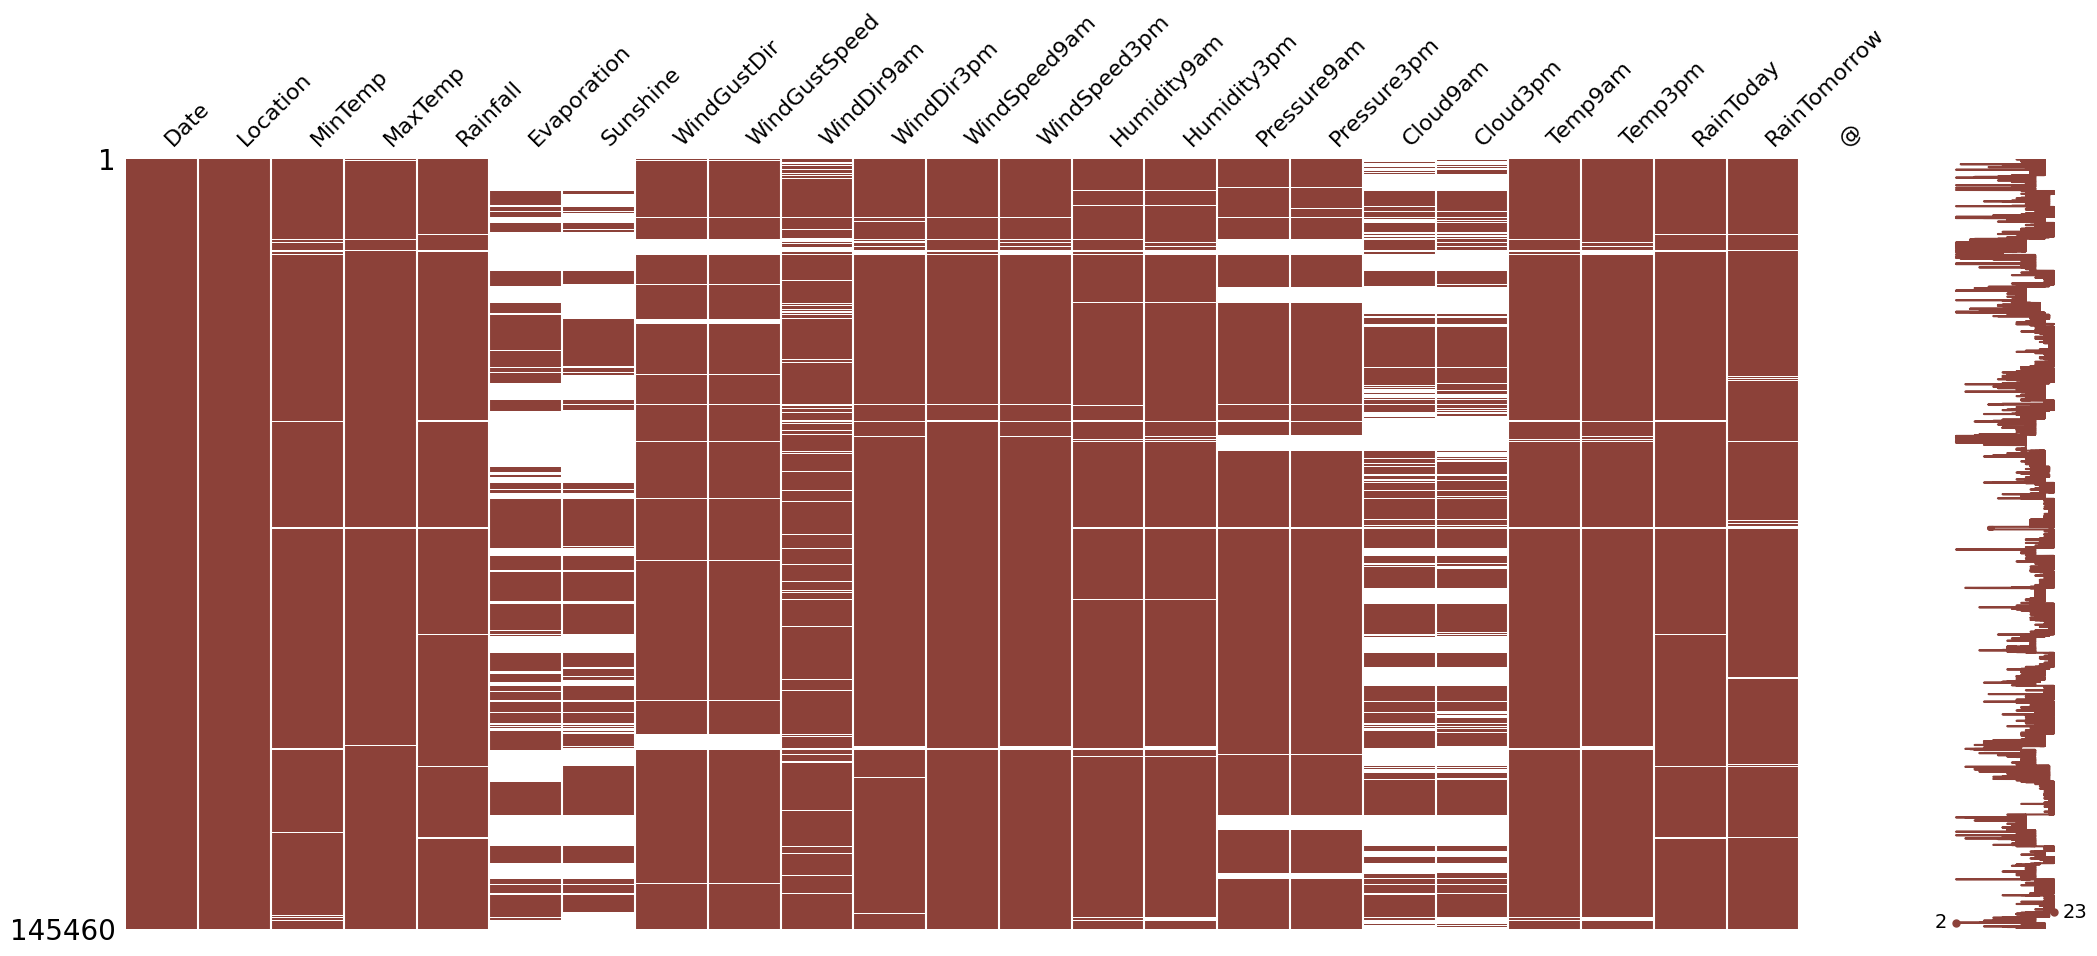

In [9]:
import missingno as msno
msno.matrix(data, color=(0.55, 0.255, 0.225), fontsize=16)

In [11]:
data_cat = data[['RainToday', 'WindGustDir', 'WindDir9am', 'WindDir3pm']].copy()

columns_to_drop = [
    'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm',
    'RainToday', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    '@'
]

data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

In [12]:
data['MinTemp'].fillna(data['MinTemp'].mean(), inplace=True)
data['MaxTemp'].fillna(data['MaxTemp'].mean(), inplace=True)
data['Rainfall'].fillna(data['Rainfall'].mean(), inplace=True)
data['WindGustSpeed'].fillna(data['WindGustSpeed'].mean(), inplace=True)
data['WindSpeed9am'].fillna(data['WindSpeed9am'].mean(), inplace=True)
data['WindSpeed3pm'].fillna(data['WindSpeed3pm'].mean(), inplace=True)
data['Humidity9am'].fillna(data['Humidity9am'].mean(), inplace=True)
data['Humidity3pm'].fillna(data['Humidity3pm'].mean(), inplace=True)
data['Pressure9am'].fillna(data['Pressure9am'].mean(), inplace=True)
data['Pressure3pm'].fillna(data['Pressure3pm'].mean(), inplace=True)
data['Temp9am'].fillna(data['Temp9am'].mean(), inplace=True)
data['Temp3pm'].fillna(data['Temp3pm'].mean(), inplace=True)


/var/folders/xp/hnltfcbx5jj2n8cdnttvrdf40000gn/T/ipykernel_10063/3671699725.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['MinTemp'].fillna(data['MinTemp'].mean(), inplace=True)
/var/folders/xp/hnltfcbx5jj2n8cdnttvrdf40000gn/T/ipykernel_10063/3671699725.py:2: ChainedAssignmentError: A value is being set on a copy of a Data

0         21.8
1         24.3
2         23.2
3         26.5
4         29.7
          ... 
145455    22.4
145456    24.5
145457    26.1
145458    26.0
145459    20.9
Name: Temp3pm, Length: 145460, dtype: float64

In [13]:
cat_names = data_cat.columns

In [14]:
import numpy as np
from sklearn.impute import SimpleImputer
imp_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

In [15]:
data_cat = imp_mode.fit_transform(data_cat)

In [16]:
data_cat = pd.DataFrame(data_cat,columns=cat_names)

In [17]:
data = pd.concat([data,data_cat],axis=1)

In [18]:
numeric_data = data.select_dtypes(include='number')
corr_matrix = numeric_data.corr()


In [19]:
cor = numeric_data.corr()

<Axes: >

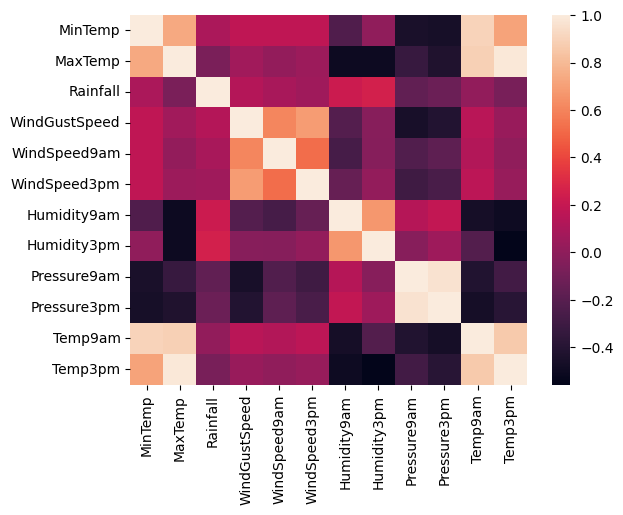

In [20]:
sns.heatmap(data=cor,xticklabels=cor.columns.values, yticklabels=cor.columns.values)

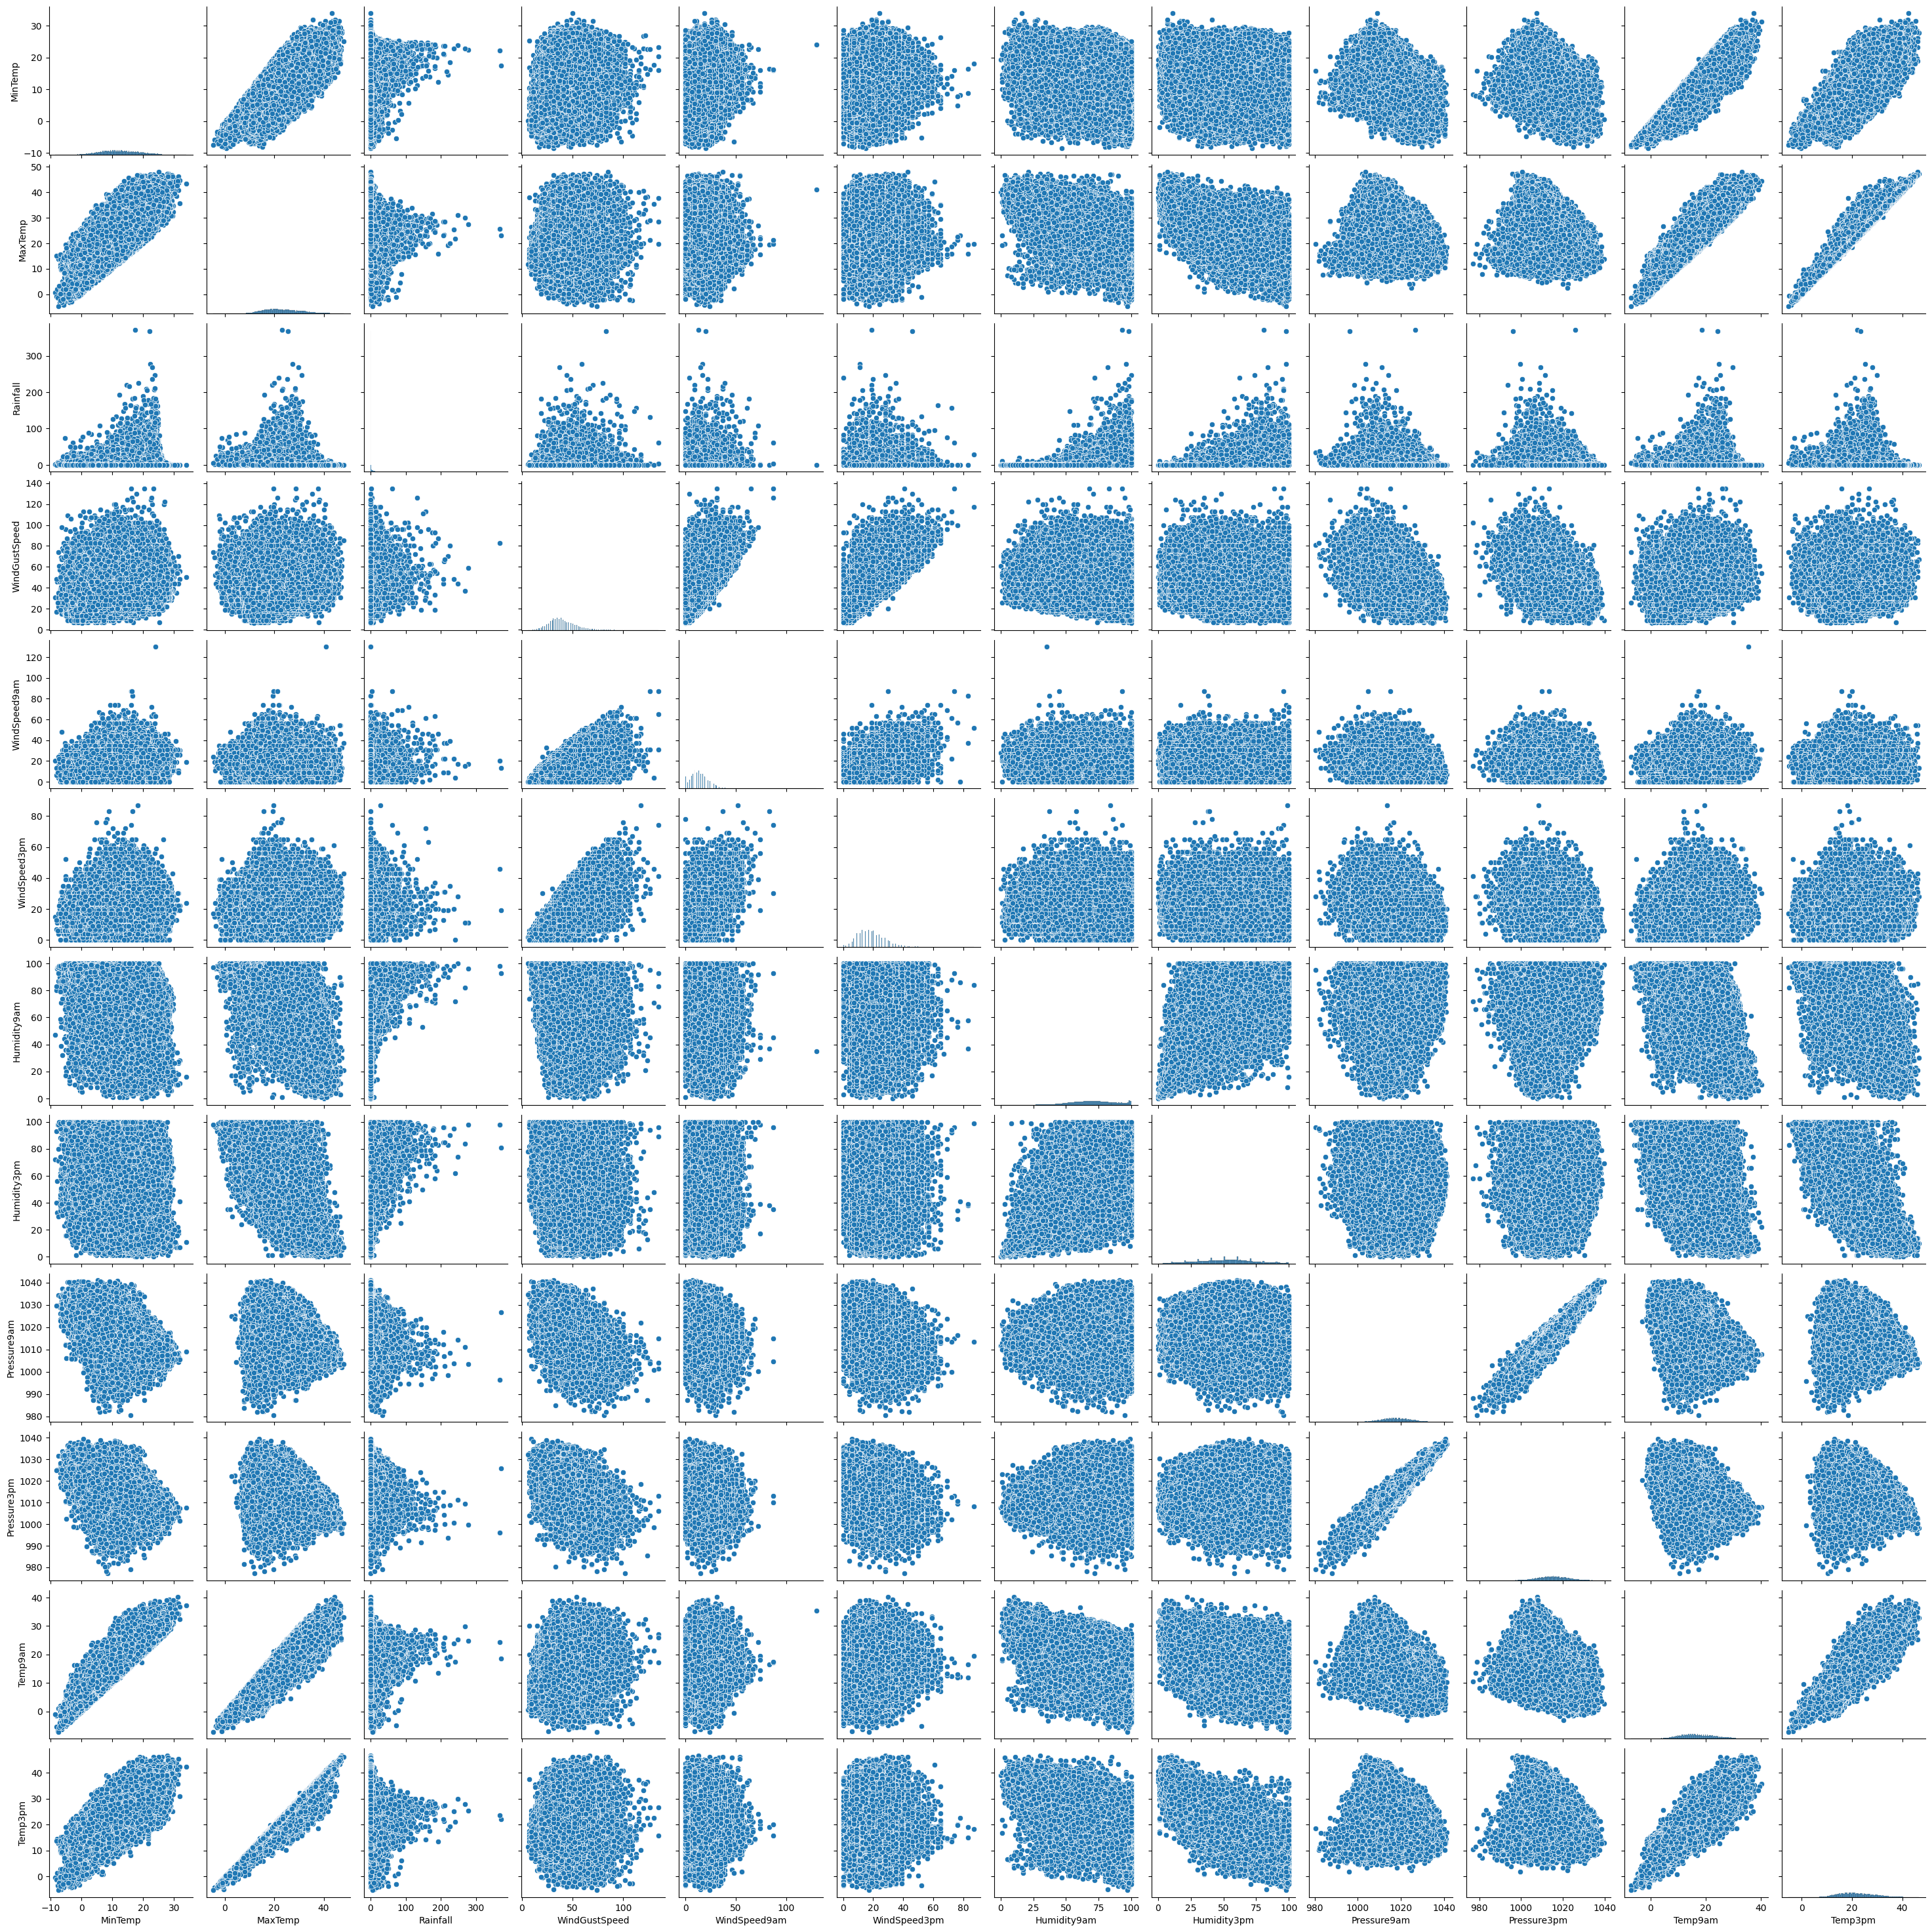

In [21]:
sns.pairplot(data)

<Axes: >

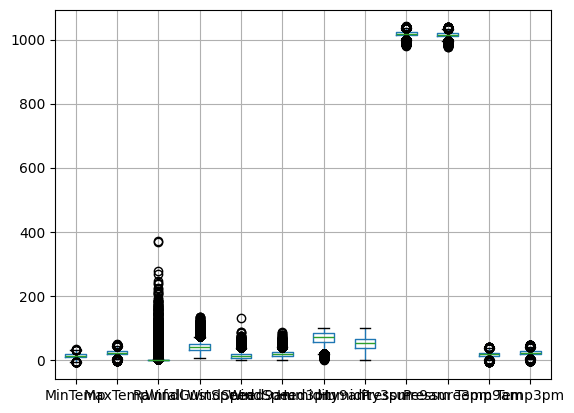

In [22]:
data.boxplot()

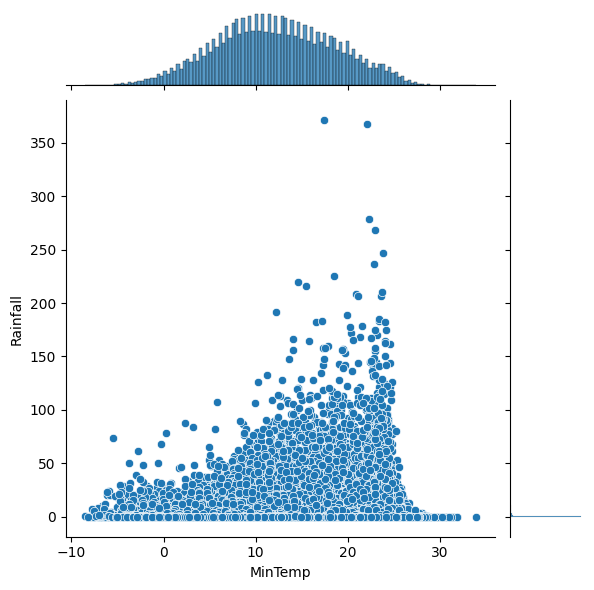

In [23]:
sns.jointplot(x=data["MinTemp"], y=data["Rainfall"])

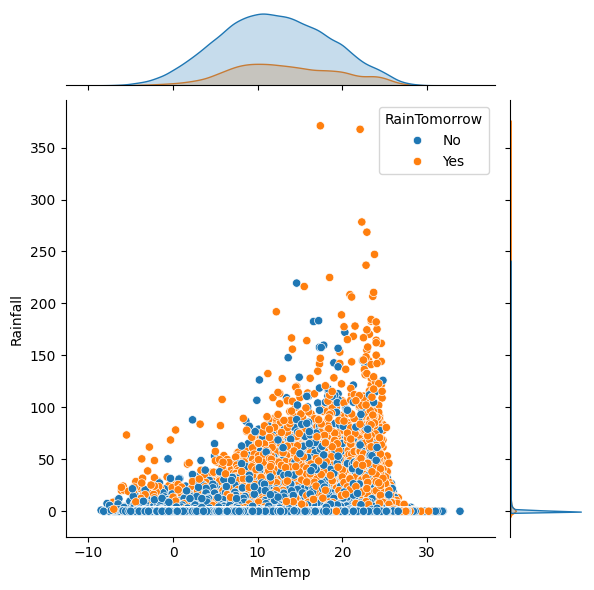

In [24]:
sns.jointplot(x=data["MinTemp"], y=data["Rainfall"], hue=data["RainTomorrow"])

<Axes: xlabel='RainTomorrow', ylabel='Count'>

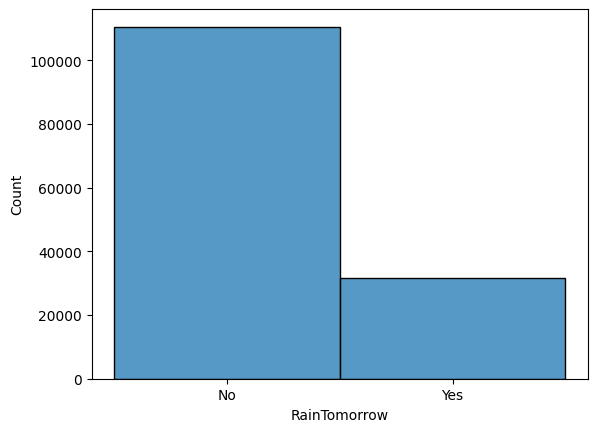

In [25]:
sns.histplot(data["RainTomorrow"])

<Axes: xlabel='MaxTemp', ylabel='Rainfall'>

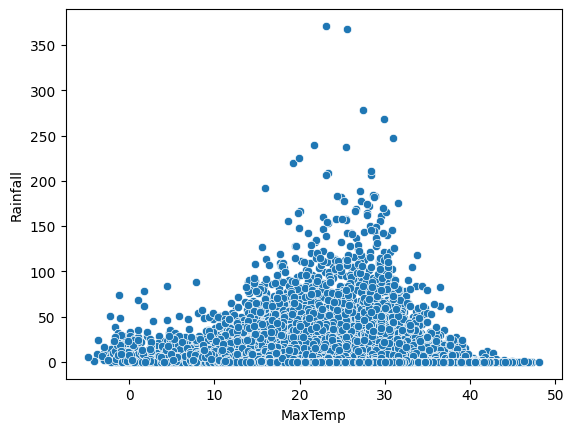

In [26]:
sns.scatterplot(x=data["MaxTemp"], y=data["Rainfall"])

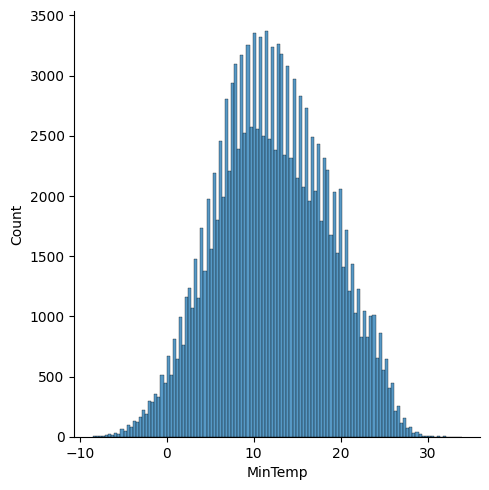

In [27]:
sns.displot(data["MinTemp"])

In [28]:
y = data['RainTomorrow']
x = data.drop('RainTomorrow',axis=1)

In [29]:
from sklearn.preprocessing import StandardScaler

In [46]:
y = data['RainTomorrow']
x = data.select_dtypes(include='number').drop('RainTomorrow', axis=1, errors='ignore')
names = x.columns

In [37]:
names

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'WindGustDir',
       'WindDir9am', 'WindDir3pm'],
      dtype='str')

In [38]:
sc = StandardScaler()

In [42]:
x = sc.fit_transform(x)

In [47]:
x = pd.DataFrame(x, columns=names )

In [48]:
from sklearn import model_selection

In [50]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=0.2, random_state=0)

In [53]:
XGBoost = xgboost.XGBRFClassifier()
Rand_forest = ensemble.RandomForestClassifier()
svm_model = svm.SVC()
Dtree = tree.DecisionTreeClassifier()
GBM = ensemble.GradientBoostingClassifier()
log = linear_model.LogisticRegression()

In [55]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)

In [57]:
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_test.mean())

In [58]:
XGBoost.fit(x_train, y_train_encoded)
Rand_forest.fit(x_train, y_train_encoded)
svm_model.fit(x_train, y_train_encoded)
Dtree.fit(x_train, y_train_encoded)
GBM.fit(x_train, y_train_encoded)
log.fit(x_train, y_train_encoded)

/Users/gopichand/Downloads/Rainfall_Project/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
p1 = XGBoost.predict(x_train)
p2 = Rand_forest.predict(x_train)
p3 = svm_model.predict(x_train)
p4 = Dtree.predict(x_train)
p5 = GBM.predict(x_train)
p6 = log.predict(x_train)

In [60]:
print("xgboost:", metrics.accuracy_score(y_train_encoded, p1))
print("Rand_forest:", metrics.accuracy_score(y_train_encoded, p2))
print("svm:", metrics.accuracy_score(y_train_encoded, p3))
print("Dtree:", metrics.accuracy_score(y_train_encoded, p4))
print("GBM:", metrics.accuracy_score(y_train_encoded, p5))
print("log:", metrics.accuracy_score(y_train_encoded, p6))

xgboost: 0.832866423759109
Rand_forest: 0.9998968788670425
svm: 0.8157139419771758
Dtree: 0.999905472294789
GBM: 0.8380310738347312
log: 0.8171232641275952


In [61]:
t1 = XGBoost.predict(x_test)
t2 = Rand_forest.predict(x_test)
t3 = svm_model.predict(x_test)
t4 = Dtree.predict(x_test)
t5 = GBM.predict(x_test)
t6 = log.predict(x_test)

In [62]:
print("xgboost:", metrics.accuracy_score(y_test_encoded, t1))
print("Rand_forest:", metrics.accuracy_score(y_test_encoded, t2))
print("svm:", metrics.accuracy_score(y_test_encoded, t3))
print("Dtree:", metrics.accuracy_score(y_test_encoded, t4))
print("GBM:", metrics.accuracy_score(y_test_encoded, t5))
print("log:", metrics.accuracy_score(y_test_encoded, t6))

xgboost: 0.8222191667812457
Rand_forest: 0.8339062285164306
svm: 0.8156537879829506
Dtree: 0.7568747421971677
GBM: 0.8289220404234842
log: 0.819400522480407


In [75]:
t1_proba = XGBoost.predict_proba(x_test)
# For binary classification, extract probability of positive class
if t1_proba.shape[1] == 2:
    t1_proba = t1_proba[:, 1]

In [63]:
conf_matrix = metrics.confusion_matrix(y_test_encoded, t1)
print(conf_matrix)

[[21319   819     0]
 [ 3711  2601     0]
 [  562    80     0]]


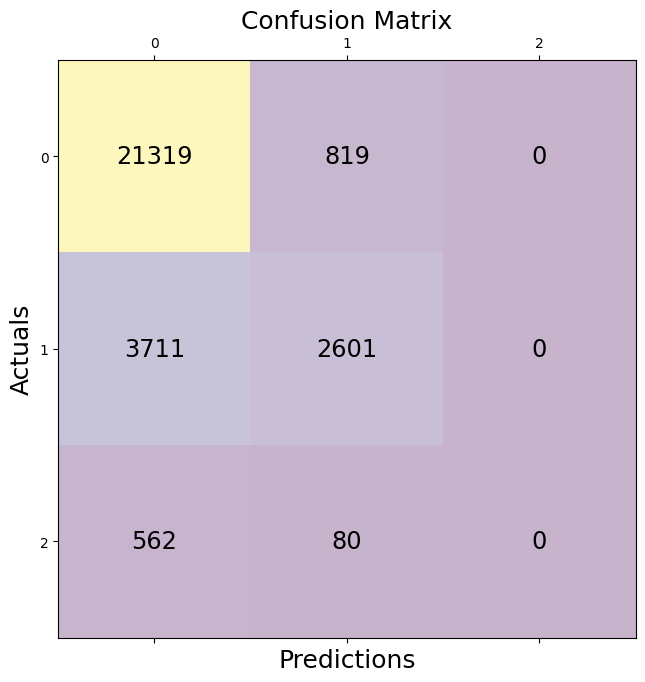

In [64]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [ ]:
Accuracy = metrics.accuracy_score(y_test_encoded, t1)
Precision = metrics.precision_score(y_test_encoded, t1, average='weighted')
Recall = metrics.recall_score(y_test_encoded, t1, average='weighted')
F1_score = metrics.f1_score(y_test_encoded, t1, average='weighted')

print("Accuracy:", Accuracy)
print("Precision:", Precision)
print("Recall:", Recall)
print("F1-score:", F1_score)


Accuracy: 0.8222191667812457
Precision: 0.7951470887304215
Recall: 0.8222191667812457
F1-score: 0.7948115386197963


/Users/gopichand/Downloads/Rainfall_Project/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


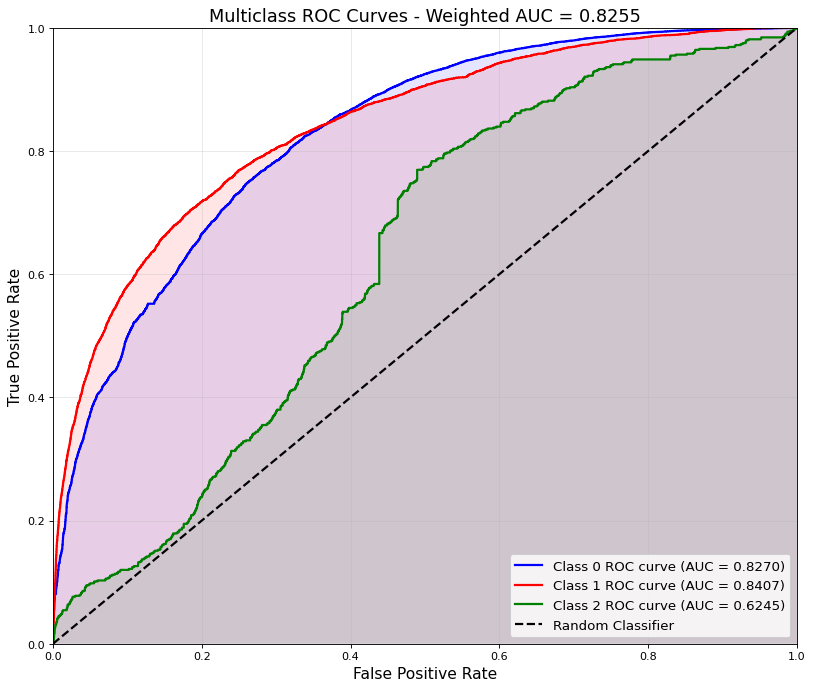

In [82]:
auc = metrics.roc_auc_score(y_test_encoded, t1_proba, multi_class='ovr', average='weighted')

n_classes = len(np.unique(y_test_encoded))
colors = ['blue', 'red', 'green']

plt.figure(figsize=(12, 10), dpi=80)

for i in range(n_classes):
    y_binary = (y_test_encoded == i).astype(int)
    fpr, tpr, thresholds = metrics.roc_curve(y_binary, t1_proba[:, i])
    auc_i = metrics.auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], linewidth=2, label=f'Class {i} ROC curve (AUC = {auc_i:.4f})')
    plt.fill_between(fpr, tpr, facecolor=colors[i], alpha=0.1)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title(f"Multiclass ROC Curves - Weighted AUC = {auc:.4f}", fontsize=16)
plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [83]:
import pickle
pickle.dump(XGBoost,open('rainfall.pkl', 'wb')) # #
pickle.dump(le, open('encoder.pkl', 'wb'))
pickle.dump(imp_mode,open('impter.pkl', 'wb'))
pickle.dump(sc,open('scale.pkl','wb'))